In [1]:
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Загружаем и изучаем датасет с HuggingFace

In [2]:
# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
train_df = pl.read_parquet(splits['train'])
test_df = pl.read_parquet(splits['test'])
train_df

archivo,nombreCientifico,fmin,fmax,duration_s,audio
str,str,f32,f32,i32,struct[2]
"""20130202T1130_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,5,"{b""RIFF~\xbc\x06\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\xaa\x01\x00\x00INFOIART\x0f\x00\x00\x00Andr""…,""20130202T1130_Acropternis_orthonyx_[-3.6795,-79.2376]_27.27s_5s.wav""}"
"""20141115T0900_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF\xe8\x0a\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST$\x01\x00\x00INFOIART\x17\x00\x00\x00Juan""…,""20141115T0900_Acropternis_orthonyx_[4.7189,-73.871]_34.27s_3s.wav""}"
"""20170203T0853_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFFV\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\x92\x01\x00\x00INFOIART\x11\x00\x00\x00Mart""…,""20170203T0853_Acropternis_orthonyx_[5.0737,-75.4378]_16.73s_3s.wav""}"
"""20160214T1130_Accipiter_striat…","""Accipiter striatus""",1961.783325,4815.286621,5,"{b""RIFF2\xbc\x06\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST^\x01\x00\x00INFOIART\x10\x00\x00\x00Ande""…,""20160214T1130_Accipiter_striatus_[-4.8846,-43.4392]_8.69s_5s.wav""}"
"""20120223T0945_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF0\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LISTl\x01\x00\x00INFOIART\x0e\x00\x00\x00Prit""…,""20120223T0945_Acropternis_orthonyx_[5.2431,-76.0964]_0.00s_3s.wav""}"
…,…,…,…,…,…
"""19980610T0648_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF\x10\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LISTL\x01\x00\x00INFOIART\x14\x00\x00\x00Bern""…,""19980610T0648_Acropternis_orthonyx_[None,None]_32.35s_3s.wav""}"
"""20160413T1430_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF6\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LISTr\x01\x00\x00INFOIART\x0b\x00\x00\x00Guy\x20""…,""20160413T1430_Acropternis_orthonyx_[5.005,-75.327]_1.18s_3s.wav""}"
"""20240918T1030_Accipiter_striat…","""Accipiter striatus""",1961.783325,4815.286621,3,"{b""RIFF\xa4\x10\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\xe0\x06\x00\x00INFOIART\x11\x00\x00\x00Vale""…,""20240918T1030_Accipiter_striatus_[45.6703,-86.9671]_157.46s_3s.wav""}"


Послушаем звуки

In [3]:
from IPython.display import Audio, display

for i in range(5):
    sample = train_df['audio'][i]
    wav_bytes = sample.get('bytes')

    if wav_bytes is None:
        raise ValueError(f"Не нашёл байты аудио в keys={list(sample.keys())}")

    print('Файл:', sample.get('path') or sample.get('filename') or 'unknown.wav')
    display(Audio(data=wav_bytes, autoplay=False))

Файл: 20130202T1130_Acropternis_orthonyx_[-3.6795,-79.2376]_27.27s_5s.wav


Файл: 20141115T0900_Acropternis_orthonyx_[4.7189,-73.871]_34.27s_3s.wav


Файл: 20170203T0853_Acropternis_orthonyx_[5.0737,-75.4378]_16.73s_3s.wav


Файл: 20160214T1130_Accipiter_striatus_[-4.8846,-43.4392]_8.69s_5s.wav


Файл: 20120223T0945_Acropternis_orthonyx_[5.2431,-76.0964]_0.00s_3s.wav


Приведем все записи к одной длине и сделаем их в моно режиме

In [5]:
import io
import numpy as np
import soundfile as sf

TARGET_SR = 16_000
TARGET_DURATION_SEC = 5
TARGET_LEN = TARGET_SR * TARGET_DURATION_SEC

def _extract_audio_bytes(audio_struct: dict) -> bytes:
    for key in ("bytes", "array", "audio"):
        if key in audio_struct and audio_struct[key] is not None:
            return audio_struct[key]
    raise KeyError(f"Не найден ключ с аудиобайтами в {list(audio_struct.keys())}")

def _to_mono_and_resample(wav_bytes: bytes, target_sr: int = TARGET_SR) -> np.ndarray:
    y, sr = sf.read(io.BytesIO(wav_bytes), dtype="float32", always_2d=False)
    if y.ndim == 2:  # stereo/multi-channel -> mono
        y = y.mean(axis=1)
    
    if sr != target_sr:        
        old_idx = np.arange(len(y), dtype=np.float32)
        new_len = int(round(len(y) * target_sr / sr))
        if len(y) > 1 and new_len > 1:
            new_idx = np.linspace(0, len(y) - 1, num=new_len, dtype=np.float32)
            y = np.interp(new_idx, old_idx, y).astype(np.float32)
        else:
            y = np.zeros((max(new_len, 1),), dtype=np.float32)

    return y.astype(np.float32)

def _fix_length(y: np.ndarray, target_len: int = TARGET_LEN) -> np.ndarray:
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    elif len(y) > target_len:
        y = y[:target_len]

    return y.astype(np.float32)

def data_prepareting(train_df):
    train_audio_fixed = []
    for a in train_df["audio"].to_list():
        wav_bytes = _extract_audio_bytes(a)
        y = _to_mono_and_resample(wav_bytes, TARGET_SR)
        y = _fix_length(y, TARGET_LEN)
        train_audio_fixed.append(y)
        
    train_df = train_df.with_columns([
        pl.Series("audio_fixed", train_audio_fixed),
        pl.lit(TARGET_SR).alias("sample_rate"),
        pl.lit(TARGET_DURATION_SEC).alias("target_duration_s"),
    ])

    return train_df

ptrain_df = data_prepareting(train_df)
ptest_df = data_prepareting(test_df)
ptrain_df.head()

archivo,nombreCientifico,fmin,fmax,duration_s,audio,audio_fixed,sample_rate,target_duration_s
str,str,f32,f32,i32,struct[2],"array[f32, 80000]",i32,i32
"""20130202T1130_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,5,"{b""RIFF~\xbc\x06\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\xaa\x01\x00\x00INFOIART\x0f\x00\x00\x00Andr""…,""20130202T1130_Acropternis_orthonyx_[-3.6795,-79.2376]_27.27s_5s.wav""}","[0.000427, 0.00029, … 0.0]",16000,5
"""20141115T0900_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF\xe8\x0a\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST$\x01\x00\x00INFOIART\x17\x00\x00\x00Juan""…,""20141115T0900_Acropternis_orthonyx_[4.7189,-73.871]_34.27s_3s.wav""}","[0.008667, 0.015345, … 0.0]",16000,5
"""20170203T0853_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFFV\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\x92\x01\x00\x00INFOIART\x11\x00\x00\x00Mart""…,""20170203T0853_Acropternis_orthonyx_[5.0737,-75.4378]_16.73s_3s.wav""}","[0.001068, 0.000963, … 0.0]",16000,5
"""20160214T1130_Accipiter_striat…","""Accipiter striatus""",1961.783325,4815.286621,5,"{b""RIFF2\xbc\x06\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST^\x01\x00\x00INFOIART\x10\x00\x00\x00Ande""…,""20160214T1130_Accipiter_striatus_[-4.8846,-43.4392]_8.69s_5s.wav""}","[-0.000458, -0.000465, … -0.000488]",16000,5
"""20120223T0945_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,3,"{b""RIFF0\x0b\x04\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LISTl\x01\x00\x00INFOIART\x0e\x00\x00\x00Prit""…,""20120223T0945_Acropternis_orthonyx_[5.2431,-76.0964]_0.00s_3s.wav""}","[0.002441, -0.007816, … 0.0]",16000,5


Извлечение признаков (MFCC)

In [6]:
import numpy as np
import librosa

def get_mfcc(df):
    sr = int(df["sample_rate"][0])
    N_MFCC = 21

    mfcc_rows = []
    for y in df["audio_fixed"].to_list():
        y = np.asarray(y, dtype=np.float32)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        mfcc_rows.append(mfcc)

    df = df.with_columns(pl.Series("mfcc", mfcc_rows, dtype=pl.Object))

    return df

train = get_mfcc(ptrain_df)
test = get_mfcc(ptest_df)

example = train["mfcc"][0]
print("MFCC shape (n_mfcc, time_frames):", example.shape)

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MFCC shape (n_mfcc, time_frames): (21, 157)


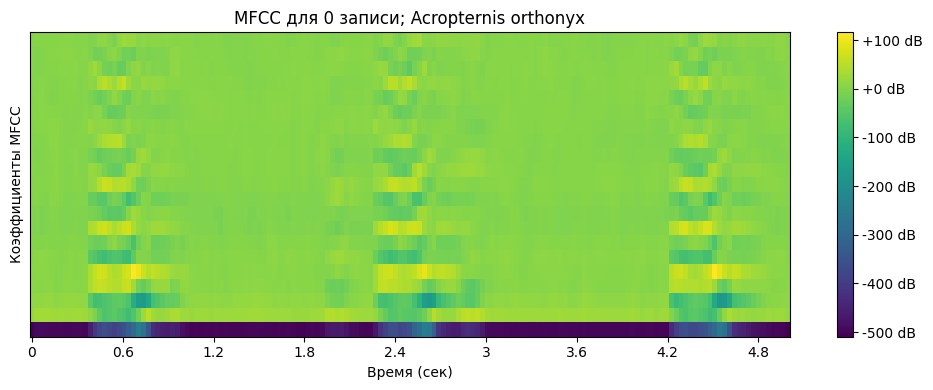

In [14]:
import matplotlib.pyplot as plt
import librosa.display

def plot_mfcc(mfcc, sr, title="MFCC"):
    plt.figure(figsize=(10, 4))
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', cmap='viridis')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(title)
    plt.xlabel("Время (сек)")
    plt.ylabel("Коэффициенты MFCC")
    plt.tight_layout()
    plt.show()

i = 0
example_mfcc = train["mfcc"][i]
example_sr = int(train["sample_rate"][i])

plot_mfcc(example_mfcc, example_sr, title=f"MFCC для {i} записи; {train['nombreCientifico'][i]}")

In [16]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

def label_encode(df):
    df = df.with_columns(pl.Series("target", le.fit_transform(df["nombreCientifico"])))
    return df

ptrain_df = label_encode(train)
ptest_df = label_encode(test)
ptrain_df[:1]

archivo,nombreCientifico,fmin,fmax,duration_s,audio,audio_fixed,sample_rate,target_duration_s,mfcc,target
str,str,f32,f32,i32,struct[2],"array[f32, 80000]",i32,i32,object,i64
"""20130202T1130_Acropternis_orth…","""Acropternis orthonyx""",2050.955322,3210.191162,5,"{b""RIFF~\xbc\x06\x00WAVEfmt\x20\x10\x00\x00\x00\x01\x00\x01\x00D\xac\x00\x00\x88X\x01\x00\x02\x00\x10\x00LIST\xaa\x01\x00\x00INFOIART\x0f\x00\x00\x00Andr""…,""20130202T1130_Acropternis_orthonyx_[-3.6795,-79.2376]_27.27s_5s.wav""}","[0.000427, 0.00029, … 0.0]",16000,5,[[-5.0824905e+02 -4.9561520e+02 -4.9343692e+02 ... -4.9889825e+02 -5.0020639e+02 -5.0939511e+02] [ 1.5543018e+01 2.7193985e+01 2.8991653e+01 ... 2.2675896e+01 2.1944992e+01 1.4106449e+01] [ 1.0498318e+01 1.1709339e+01 1.1252055e+01 ... 8.0639305e+00 8.8010406e+00 9.6919136e+00] ... [-1.2305882e+00 -2.3320618e+00 7.7410209e-01 ... -1.8618590e-01 2.3876905e+00 3.7695730e+00] [-3.9132100e-01 -1.6215409e+00 2.1072745e-01 ... 6.9227567e+00 8.3672466e+00 4.3489075e+00] [ 7.2144127e-01 9.8222995e-01 2.2886448e+00 ... 9.0851879e+00 9.9046144e+00 3.3672419e+00]],1


### Визуализация датасета

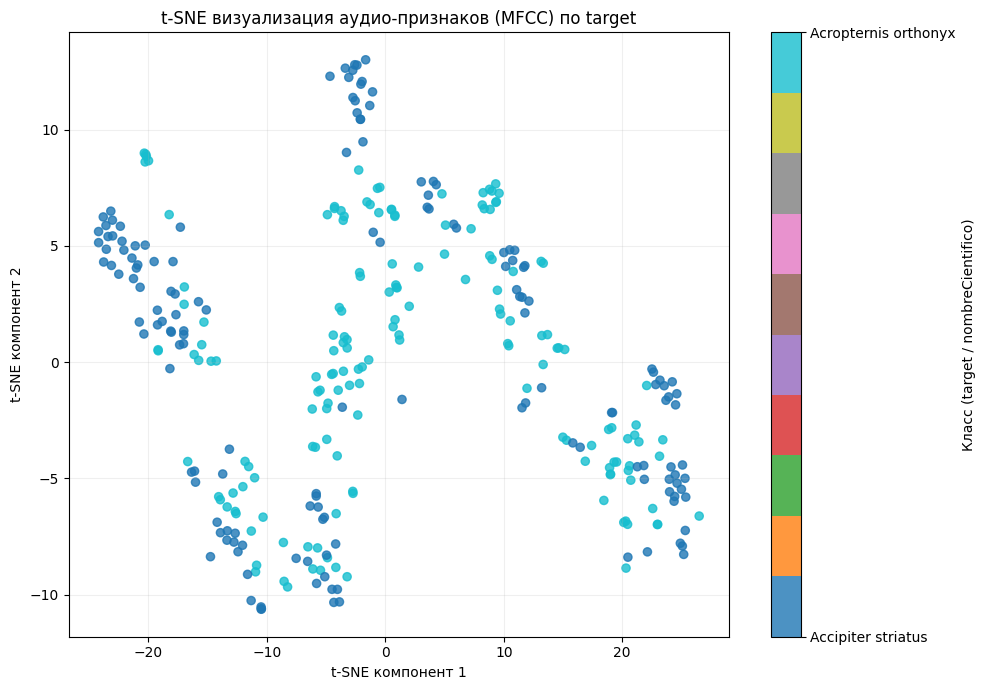

In [17]:
from sklearn.manifold import TSNE

X = []
for mfcc in ptrain_df["mfcc"].to_list():
    mfcc = np.asarray(mfcc, dtype=np.float32)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)
    X.append(np.concatenate([mfcc_mean, mfcc_std]))

X = np.vstack(X)
y = ptrain_df["target"].to_numpy()
class_names = le.classes_

perplexity = min(30, max(5, len(X) // 3))
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
)
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    cmap="tab10",
    s=35,
    alpha=0.8,
)

cbar = plt.colorbar(scatter, ticks=np.arange(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Класс (target / nombreCientifico)")

plt.title("t-SNE визуализация аудио-признаков (MFCC) по target")
plt.xlabel("t-SNE компонент 1")
plt.ylabel("t-SNE компонент 2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Возьмем метрику F1-score для классификации

In [18]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train = np.array([mfcc.flatten() for mfcc in ptrain_df["mfcc"].to_list()])
Y_train = ptrain_df["target"].to_numpy()

X_test = np.array([mfcc.flatten() for mfcc in ptest_df["mfcc"].to_list()])
Y_test = ptest_df["target"].to_numpy()

SVM

In [19]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-score: {f1}")

F1-score: 0.7371308016877637


LinearRegression

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-score: {f1}")

F1-score: 0.9374109827504352


CatBoost

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(n_estimators=150, verbose=50, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-score: {f1}")

1
Learning rate set to 0.036071
0:	learn: 0.6623500	total: 310ms	remaining: 46.2s
50:	learn: 0.1604955	total: 9.4s	remaining: 18.3s
100:	learn: 0.0725002	total: 18s	remaining: 8.75s
149:	learn: 0.0370917	total: 26.3s	remaining: 0us
F1-score: 0.9374109827504352


## Попробуем использовать предобученную модель

In [27]:
import torchaudio
import torch
import os

# 1. Загружаем предобученную модель и её параметры (bundle)
# WAV2VEC2_BASE обучена на 16кГц, что совпадает с нашим TARGET_SR
bundle = torchaudio.pipelines.WAV2VEC2_BASE
dl_model = bundle.get_model()
dl_model.eval() 

def extract_dl_embeddings(df):
    embeddings_list = []
    
    with torch.no_grad():
        # Проходим по списку аудиозаписей
        for y_raw in df["audio_fixed"].to_list():
            # Явно превращаем в numpy array, если это был список, а затем в тензор
            y_np = np.asarray(y_raw, dtype=np.float32)
            waveform = torch.from_numpy(y_np).unsqueeze(0) # [1, T]
            
            # Извлекаем признаки
            # Модель возвращает кортеж (features_list, length_list)
            features_tuple = dl_model.extract_features(waveform)
            
            # features_tuple[0] — это список выходов с разных слоев. Берем последний.
            last_layer_features = features_tuple[0][-1] # [1, time_frames, 768]
            
            # Агрегируем (Mean Pooling) по временной оси (dim=1)
            embedding = torch.mean(last_layer_features, dim=1).squeeze().numpy()
            embeddings_list.append(embedding)
            
    return np.array(embeddings_list)

if not os.path.exists('X_train_dl.npy') or not os.path.exists('X_test_dl.npy'):
    X_train_dl = extract_dl_embeddings(ptrain_df)
    X_test_dl = extract_dl_embeddings(ptest_df)

    np.save('X_train_dl.npy', X_train_dl)
    np.save('X_test_dl.npy', X_test_dl)

X_train_dl = np.load('X_train_dl.npy')
X_test_dl = np.load('X_test_dl.npy')

print(f"Новая размерность признаков: {X_train_dl.shape}") 

Новая размерность признаков: (320, 768)


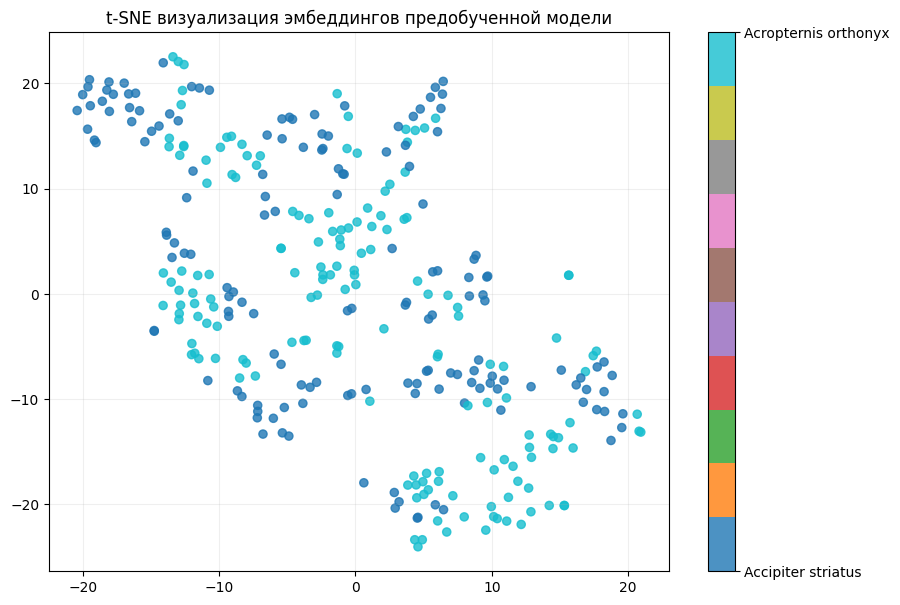

In [28]:
tsne_dl = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_2d_dl = tsne_dl.fit_transform(X_train_dl)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d_dl[:, 0], X_2d_dl[:, 1], c=y, cmap="tab10", s=35, alpha=0.8)
cbar = plt.colorbar(scatter, ticks=np.arange(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title("t-SNE визуализация эмбеддингов предобученной модели")
plt.grid(alpha=0.2)
plt.show()

In [29]:
# SVM
model_dl = SVC(kernel='rbf')
model_dl.fit(X_train_dl, Y_train)
y_pred_dl = model_dl.predict(X_test_dl)
f1_dl = f1_score(Y_test, y_pred_dl, average='weighted')

print(f"F1-score Wav2Vec 2.0 (SVM): {f1_dl:.4f}")

# LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-score Wav2Vec 2.0 (LogisticRegression): {f1}")

# CatBoost
model = CatBoostClassifier(n_estimators=150, verbose=50, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-score Wav2Vec 2.0 (CatBoost): {f1}")

F1-score Wav2Vec 2.0 (SVM): 0.9248
F1-score Wav2Vec 2.0 (LogisticRegression): 0.9374109827504352
Learning rate set to 0.036071
0:	learn: 0.6623500	total: 229ms	remaining: 34.1s
50:	learn: 0.1604955	total: 6.75s	remaining: 13.1s
100:	learn: 0.0725002	total: 13.3s	remaining: 6.44s
149:	learn: 0.0370917	total: 20.1s	remaining: 0us
F1-score Wav2Vec 2.0 (CatBoost): 0.9374109827504352


Напишем ДЛ модель

In [30]:
class AudioClassifier(nn.Module):
    def __init__(self, num_input, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(num_input, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.head(x)

model = AudioClassifier(num_input=X_train_dl.shape[1], num_classes=len(le.classes_))

In [31]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_dl, dtype=torch.float32)
y_train_t = torch.tensor(Y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_t = torch.tensor(Y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_head = AudioClassifier(X_train_dl.shape[1], len(le.classes_)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_head.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model_head.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_head(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch + 1} / {epochs}], Loss: {total_loss/len(train_loader):.4f}")

model_head.eval()
all_preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = model_head(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

f1_nn = f1_score(Y_test, all_preds, average='weighted')
print(f"F1-score сетки: {f1_nn:.4f}")

Эпоха [10 / 50], Loss: 0.1215
Эпоха [20 / 50], Loss: 0.0263
Эпоха [30 / 50], Loss: 0.0089
Эпоха [40 / 50], Loss: 0.0042
Эпоха [50 / 50], Loss: 0.0030
F1-score сетки: 0.9498


In [32]:
class FullBirdModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
        
    def forward(self, x):
        features_tuple = self.backbone.extract_features(x)
        last_layer_features = features_tuple[0][-1]
        
        embedding = torch.mean(last_layer_features, dim=1)

        logits = self.head(embedding)
        return logits, embedding

full_model = FullBirdModel(dl_model, model_head).to(device)
for param in full_model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(full_model.parameters(), lr=1e-5)

X_train_raw = torch.tensor(np.stack(ptrain_df["audio_fixed"].to_list()), dtype=torch.float32)
X_test_raw = torch.tensor(np.stack(ptest_df["audio_fixed"].to_list()), dtype=torch.float32)

train_ds_ft = TensorDataset(X_train_raw, y_train_t)
train_loader_ft = DataLoader(train_ds_ft, batch_size=8, shuffle=True)

epochs_ft = 3
print("Начинаем Fine-tuning...")
for epoch in range(epochs_ft):
    full_model.train()
    for batch_X, batch_y in train_loader_ft:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer_ft.zero_grad()
        logits, _ = full_model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer_ft.step()
    print(f"Epoch {epoch+1} finished")

full_model.eval()
X_test_ft_list = []
all_preds_ft = []

with torch.no_grad():
    test_loader_ft = DataLoader(TensorDataset(X_test_raw, y_test_t), batch_size=8)
    for batch_X, batch_y in test_loader_ft:
        batch_X = batch_X.to(device)
        logits, emb = full_model(batch_X)
        
        X_test_ft_list.append(emb.cpu().numpy())
        _, preds = torch.max(logits, 1)
        all_preds_ft.extend(preds.cpu().numpy())

X_test_ft = np.vstack(X_test_ft_list)
f1_ft = f1_score(Y_test, all_preds_ft, average='weighted')
print(f"\nF1-score после Fine-tuning: {f1_ft:.4f}")

tsne_ft = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_2d_ft = tsne_ft.fit_transform(X_test_ft)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d_ft[:, 0], X_2d_ft[:, 1], c=Y_test, cmap="tab10", s=35)
plt.title("t-SNE после Fine-tuning (Test Set)")
plt.show()

Начинаем Fine-tuning...


KeyboardInterrupt: 

In [ ]:
from scipy.spatial.distance import pdist, squareform

# 1. Считаем матрицу расстояний между всеми записями тестового набора
# Используем косинусное расстояние (хорошо для векторов нейросетей)
dist_matrix = squareform(pdist(X_test_ft, metric='cosine'))

# Чтобы не найти расстояние от записи до самой себя (оно 0), заполним диагональ бесконечностью
np.fill_diagonal(dist_matrix, np.inf)

# 2. Находим индексы
min_dist_idx = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
max_dist_idx = np.unravel_index(np.argmax(dist_matrix.replace(np.inf, -1) if hasattr(dist_matrix, 'replace') else dist_matrix), dist_matrix.shape) 
# Для макс расстояния заменим inf обратно на реальные значения
max_dist_val = np.max(dist_matrix[dist_matrix != np.inf])
max_dist_idx = np.where(dist_matrix == max_dist_val)
idx_far1, idx_far2 = max_dist_idx[0][0], max_dist_idx[1][0]
idx_near1, idx_near2 = min_dist_idx

print(f"Самые близкие записи: {idx_near1} и {idx_near2} (расстояние {dist_matrix[idx_near1, idx_near2]:.4f})")
print(f"Самые дальние записи: {idx_far1} и {idx_far2} (расстояние {dist_matrix[idx_far1, idx_far2]:.4f})")

# 3. Функция для отрисовки спектрограммы (Mel-spectrogram)
def plot_mel_spec(idx, df, title_prefix=""):
    y = np.asarray(df["audio_fixed"][idx], dtype=np.float32)
    sr = df["sample_rate"][idx]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    plt.figure(figsize=(5, 3))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title(f"{title_prefix} | Class: {df['nombreCientifico'][idx]}")
    plt.tight_layout()

# Визуализируем
print("\nВизуализация спектрограмм:")
plot_mel_spec(idx_near1, ptest_df, "Близкая 1")
plot_mel_spec(idx_near2, ptest_df, "Близкая 2")
plot_mel_spec(idx_far1, ptest_df, "Дальняя 1")
plot_mel_spec(idx_far2, ptest_df, "Дальняя 2")
plt.show()